In [1]:
import pandas as pd
df = pd.read_csv("Unemployment in India.csv")
df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.rename(columns={
    'Estimated Unemployment Rate (%)':'Unemployment_rate',
    'Estimated Employed':'Employed',
    'Estimated Labour Participation Rate (%)':'Labour_participation'
}, inplace=True)


In [7]:
df.isnull().sum()


Region                  28
Date                    28
Frequency               28
Unemployment_rate       28
Employed                28
Labour_participation    28
Area                    28
dtype: int64

In [8]:
# Drop rows for empty values
df = df.dropna(how='all')

In [9]:
# Drop rows where critical columns are missing
df = df.dropna(subset=['Date','Region'])

In [10]:
df.isnull().sum()

Region                  0
Date                    0
Frequency               0
Unemployment_rate       0
Employed                0
Labour_participation    0
Area                    0
dtype: int64

In [11]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Region                740 non-null    str           
 1   Date                  740 non-null    datetime64[us]
 2   Frequency             740 non-null    str           
 3   Unemployment_rate     740 non-null    float64       
 4   Employed              740 non-null    float64       
 5   Labour_participation  740 non-null    float64       
 6   Area                  740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 46.2 KB


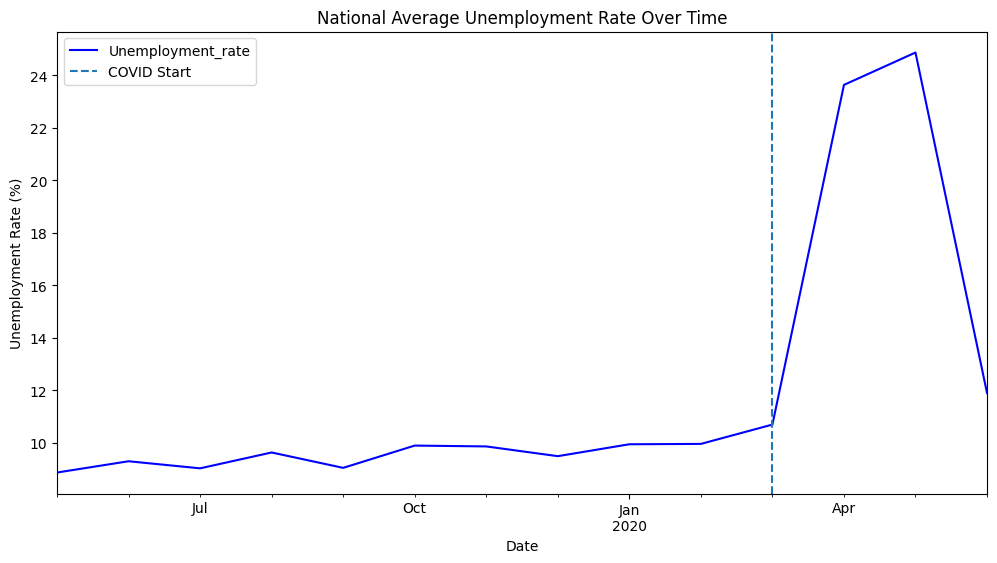

In [23]:
national_trend = df.groupby('Date')['Unemployment_rate'].mean()
national_trend.plot(figsize=(12,6), color='blue')
plt.title("National Average Unemployment Rate Over Time")
plt.ylabel("Unemployment Rate (%)")
plt.axvline(pd.to_datetime("2020-03-01"), linestyle="--", label="COVID Start")
plt.legend()
plt.show()


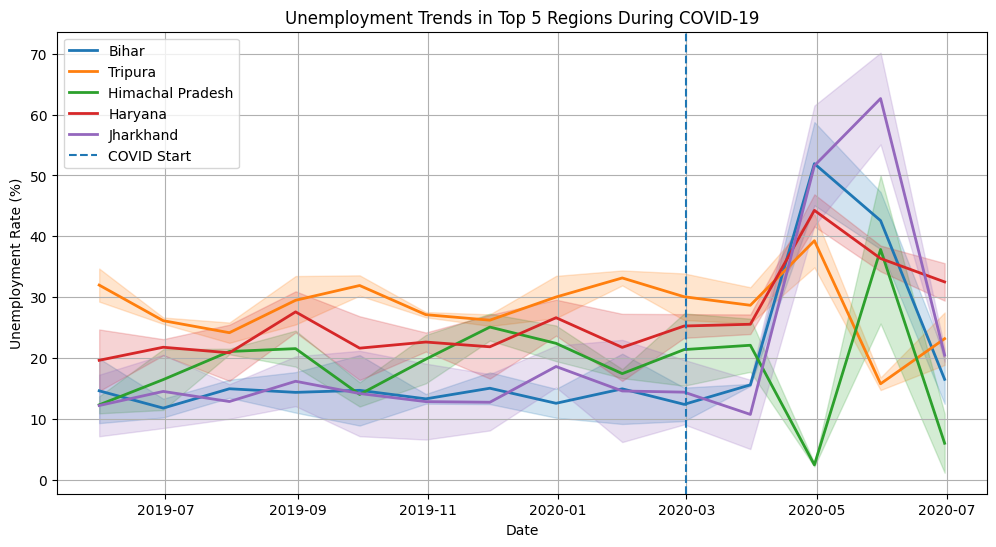

In [19]:
top_regions = df.groupby('Region')['Unemployment_rate'].mean() \
    .sort_values(ascending=False).head(5).index

subset = df[df['Region'].isin(top_regions)]
subset = subset.sort_values(by="Date")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.lineplot(
    data=subset,
    x='Date',
    y='Unemployment_rate',
    hue='Region',
    linewidth=2
)

plt.axvline(pd.to_datetime("2020-03-01"), linestyle="--", label="COVID Start")

plt.title("Unemployment Trends in Top 5 Regions During COVID-19")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)
plt.legend()

plt.show()

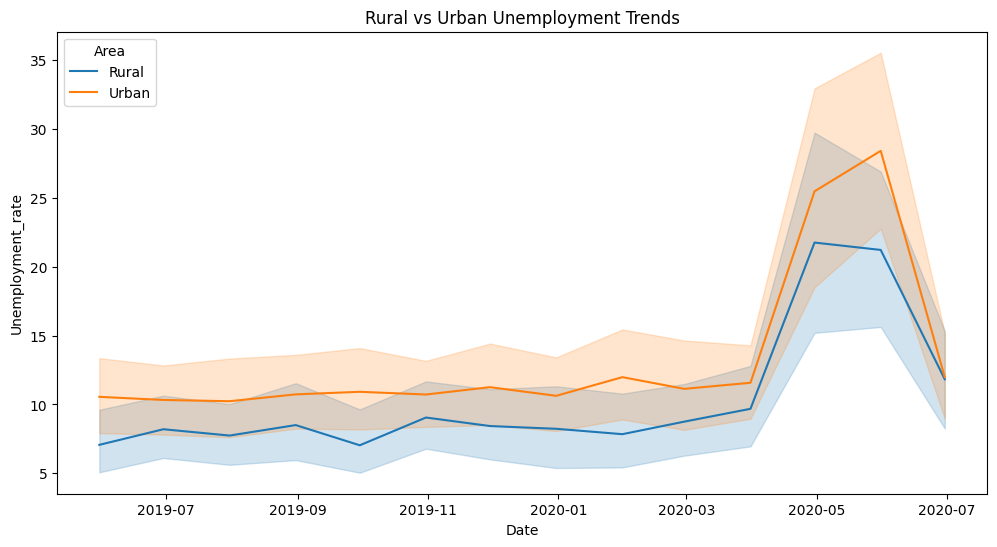

In [20]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Unemployment_rate', hue='Area')
plt.title("Rural vs Urban Unemployment Trends")
plt.show()

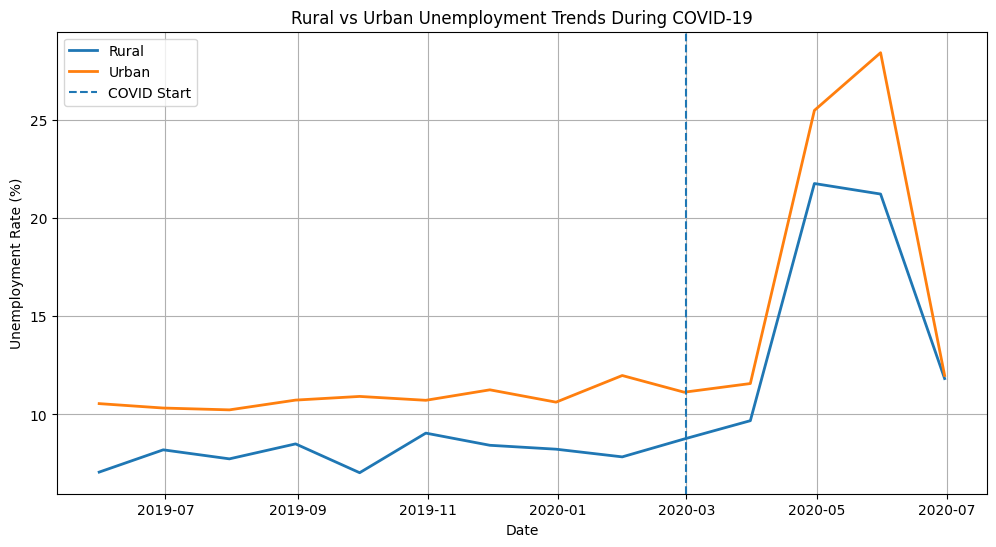

In [21]:
area_trend = df.groupby(['Date', 'Area'])['Unemployment_rate'].mean().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=area_trend,
    x='Date',
    y='Unemployment_rate',
    hue='Area',
    linewidth=2
)

plt.axvline(pd.to_datetime("2020-03-01"), linestyle="--", label="COVID Start")

plt.title("Rural vs Urban Unemployment Trends During COVID-19")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)
plt.legend()

plt.show()

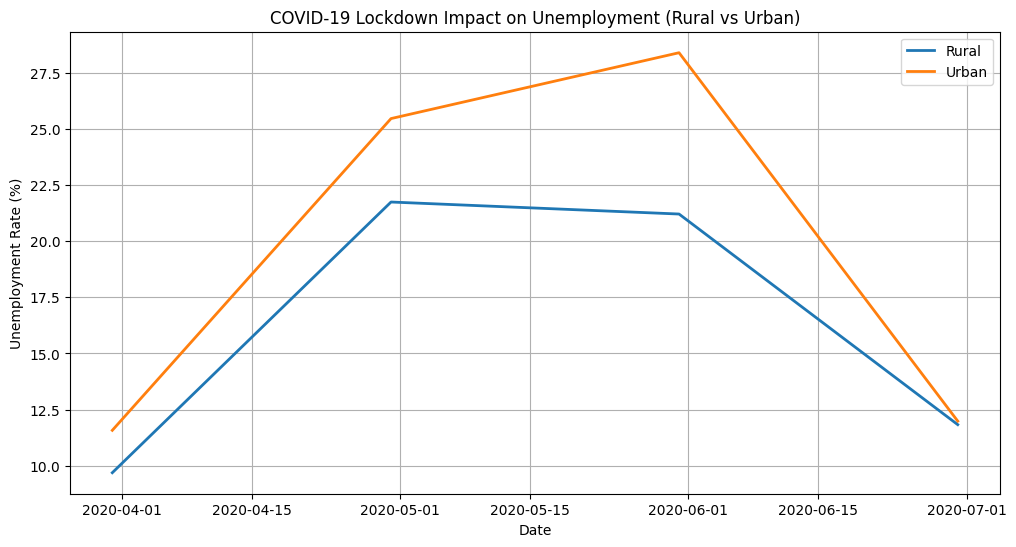

In [22]:
covid_period = df[
    (df['Date'] >= '2020-03-01') & 
    (df['Date'] <= '2020-06-30')
]

covid_trend = covid_period.groupby(['Date', 'Area'])['Unemployment_rate'] \
    .mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.lineplot(
    data=covid_trend,
    x='Date',
    y='Unemployment_rate',
    hue='Area',
    linewidth=2
)

plt.title("COVID-19 Lockdown Impact on Unemployment (Rural vs Urban)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)
plt.legend()

plt.show()